# Fitting marginals for three assets



We now extend the single-asset workflow of `2_simple_portfolio_optimization.ipynb` to three assets: the market excess return `m`, value `hml`, and size `smb`.



The pipeline is split across three notebooks:



- **This notebook (4):** fit candidate marginal distributions to each asset on fold 1, and produce the PIT series we'll feed to the copula step.

- **Notebook 5:** for each marginal family, PIT the fold-1 returns and fit two candidate copulas (Gaussian and Student-t). This gives us **6 joint models** (3 marginal families × 2 copulas).

- **Notebook 6:** for each γ and each of the 6 joint models, solve for the optimal portfolio weights f★ on simulated draws, then **select the joint model by realized mean utility on fold 2** (mirroring the single-asset selection rule in notebook 2).

In [1]:
import pandas as pd

import numpy as np

from scipy.stats import norm, t, johnsonsu

import requests

from io import BytesIO

from zipfile import ZipFile

import seaborn as sns

import matplotlib.pyplot as plt

import warnings, pickle, os



warnings.filterwarnings("ignore")

np.random.seed(607)

## Data: Fama–French monthly factors, four folds



We pull Ken French's monthly factor file, build excess-return-like quantities

$m = (\text{Mkt}-\text{RF})/(1+\text{RF})$, $hml = \text{HML}/(1+\text{RF})$, $smb = \text{SMB}/(1+\text{RF})$, and split into four time-period folds.



- **fold 1** (1926-07 to 1983-12): training — fit marginals and copulas here.

- **fold 2** (1983-01 to 2012-12): validation — model selection by realized utility happens here.

- **fold 3** (2013-01 to 2018-12) and **fold 4** (2019-01+): held-out test windows.

In [2]:
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

response = requests.get(url)



with ZipFile(BytesIO(response.content)) as zfile:

    csv_name = next(n for n in zfile.namelist() if n.lower().endswith('.csv'))

    with zfile.open(csv_name) as file:

        csv_data = pd.read_csv(file, skiprows=3, index_col=0)



csv_data = csv_data.apply(pd.to_numeric, errors='coerce').dropna()

csv_data = csv_data[csv_data.index.map(lambda x: x.isdigit() and len(x) == 6)]



csv_data['m']   = (csv_data['Mkt-RF'] / 100) / (1 + csv_data['RF'] / 100)

csv_data['hml'] = (csv_data['HML']    / 100) / (1 + csv_data['RF'] / 100)

csv_data['smb'] = (csv_data['SMB']    / 100) / (1 + csv_data['RF'] / 100)

csv_data['r_f'] =  csv_data['RF']     / 100



fold1 = csv_data.loc['192607':'198312']

fold2 = csv_data.loc['198301':'201212']

fold3 = csv_data.loc['201301':'201812']

fold4 = csv_data.loc['201901':]



print(f"fold1: {len(fold1)} months   fold2: {len(fold2)} months   "

      f"fold3: {len(fold3)} months   fold4: {len(fold4)} months")

fold1: 690 months   fold2: 360 months   fold3: 72 months   fold4: 87 months


## Fit three marginal families to each asset on fold 1



For each asset $a \in \{m, hml, smb\}$ and each family $F \in \{\text{Normal}, \text{Student-t}, \text{Johnson-}S_U\}$, we fit $F$ to the fold-1 observations of $a$ by maximum likelihood. We do **not** select a winner here. Selection is decision-based and happens in notebook 6.

In [3]:
factors = ['m', 'hml', 'smb']

families = ['Normal', 'Student t', 'Johnson Su']



fitters = {

    'Normal':     norm,

    'Student t':  t,

    'Johnson Su': johnsonsu,

}



# marginal_params[asset][family] = scipy params tuple

marginal_params = {a: {} for a in factors}



for a in factors:

    x = fold1[a].values

    for f in families:

        marginal_params[a][f] = fitters[f].fit(x)



for a in factors:

    print(f"--- {a} ---")

    for f in families:

        print(f"  {f:11s} params = {marginal_params[a][f]}")

--- m ---
  Normal      params = (0.006498905639273017, 0.05832591211102045)
  Student t   params = (3.454321528154351, 0.008628757057419827, 0.03804335191754441)
  Johnson Su  params = (0.26157413861083245, 1.2575811841327942, 0.01983183211724124, 0.049430789316902715)
--- hml ---
  Normal      params = (0.004650562434693083, 0.03825004401315959)
  Student t   params = (2.5394554356267034, 0.002065617692141702, 0.019797666853941485)
  Johnson Su  params = (-0.16068131469004213, 1.0321159679384764, -0.0013503819543800818, 0.02161569523230021)
--- smb ---
  Normal      params = (0.003033206890066506, 0.0324983672803275)
  Student t   params = (3.977305267672415, 0.0015523930989357125, 0.021791943041726478)
  Johnson Su  params = (-0.21128335266898265, 1.3889354112307797, -0.003527287637425401, 0.03148614745044295)


## PIT each asset's fold-1 sample through each marginal family



For the copula step in notebook 5 we need PIT-transformed fold-1 data **for every choice of marginal family**, not just one. We pre-compute all 3×3 = 9 PIT series here.

In [4]:
def pit(x, family, params):

    return fitters[family].cdf(x, *params)



pit_fold1 = {f: pd.DataFrame(index=fold1.index) for f in families}



for f in families:

    for a in factors:

        pit_fold1[f][a] = pit(fold1[a].values, f, marginal_params[a][f])



for f in families:

    print(f"PIT fold-1 under {f} marginals — head:")

    print(pit_fold1[f].head(3), "\n")

PIT fold-1 under Normal marginals — head:
               m       hml       smb
192607  0.649133  0.228122  0.190443
192608  0.633100  0.808399  0.328794
192609  0.481487  0.456783  0.304726 

PIT fold-1 under Student t marginals — head:
               m       hml       smb
192607  0.686208  0.148210  0.141748
192608  0.665278  0.908239  0.292609
192609  0.452933  0.471367  0.263073 

PIT fold-1 under Johnson Su marginals — head:
               m       hml       smb
192607  0.687727  0.135705  0.132784
192608  0.665139  0.893150  0.289847
192609  0.444458  0.471106  0.258798 



## Sanity check: scatter of PIT values under one marginal family



A PIT scatter should fill the unit square; deviations from uniformity reveal misspecification of the marginal. Dependence structure (the copula) is the off-diagonal pattern in this plot. We show the Student-t-marginals case as a reference; the other two families look similar.

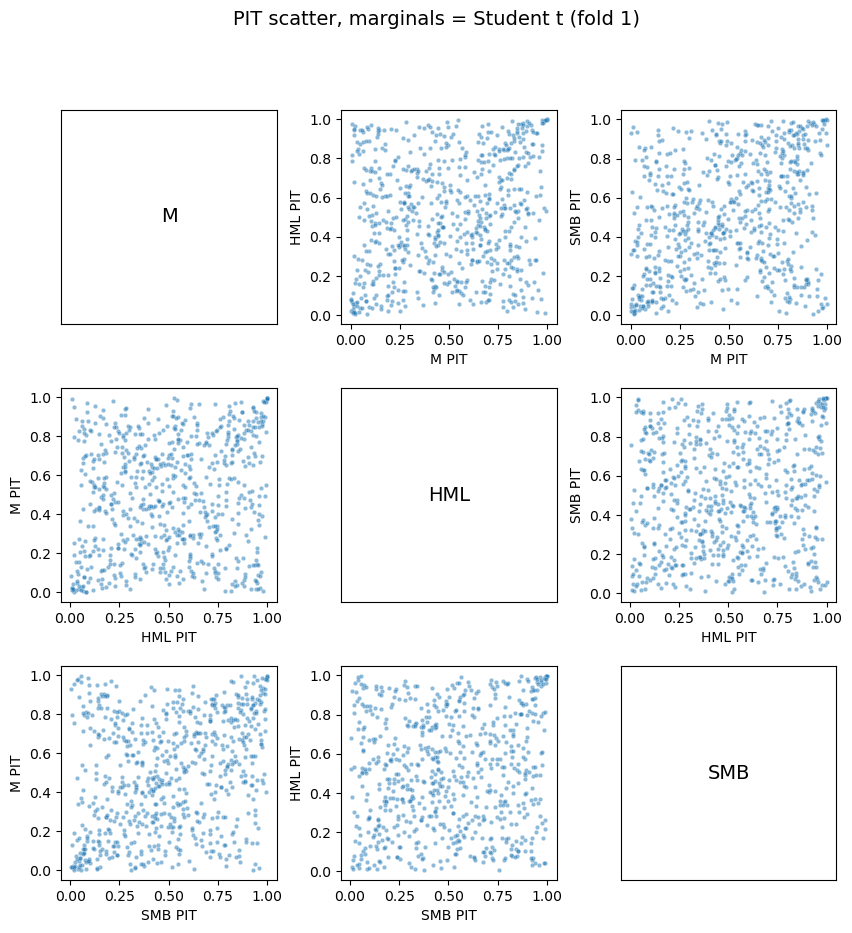

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

fig.subplots_adjust(hspace=0.3, wspace=0.3)

ref_family = 'Student t'



for i, row_factor in enumerate(factors):

    for j, col_factor in enumerate(factors):

        if i == j:

            axes[i, j].text(0.5, 0.5, row_factor.upper(), fontsize=14, ha='center', va='center')

            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

        else:

            sns.scatterplot(

                x=pit_fold1[ref_family][row_factor],

                y=pit_fold1[ref_family][col_factor],

                alpha=0.5, ax=axes[i, j], s=10,

            )

            axes[i, j].set_xlabel(f"{row_factor.upper()} PIT")

            axes[i, j].set_ylabel(f"{col_factor.upper()} PIT")



plt.suptitle(f"PIT scatter, marginals = {ref_family} (fold 1)", fontsize=14)

plt.show()

## Persist results for notebooks 5 and 6



We save the fitted marginals, the fold-1 PIT panels under each marginal family, and the raw folds (for fold-2 realized-utility scoring later). Notebook 5 picks up from `marginal_params` and `pit_fold1`. Notebook 6 also needs `fold2`, `fold3`, `fold4` and the risk-free leg `r_f`.

In [6]:
OUT = "three_asset_state.pkl"

state = {

    "factors":         factors,

    "families":        families,

    "marginal_params": marginal_params,

    "pit_fold1":       {f: df for f, df in pit_fold1.items()},

    "fold1":           fold1[factors + ['r_f']],

    "fold2":           fold2[factors + ['r_f']],

    "fold3":           fold3[factors + ['r_f']],

    "fold4":           fold4[factors + ['r_f']],

}

with open(OUT, "wb") as fh:

    pickle.dump(state, fh)



print(f"wrote {OUT} ({os.path.getsize(OUT):,} bytes)")

wrote three_asset_state.pkl (102,810 bytes)
